# 01. 합성 캠페인 데이터 탐색

**목적**: `backend/src/data/generator.py`가 만든 데이터가 `patterns.py`의 도메인 가정을
충실히 반영하는지 시각적으로 검증한다.

검증 항목:
1. 기본 분포 (카테고리·메시지타입·캠페인 목적)
2. **시간대 효과** — 외식업 11/17시 피크, 금융 9-11시 피크 등이 보이는지
3. **요일 효과** — B2C 주말 강세, 금융·공공 평일 화-목 강세
4. **메시지 타입 효과** — SMS < LMS < MMS < RCS 순
5. **캠페인 목적 효과** — 리텐션 > 알림 > 프로모션 > 재활성화
6. **깔때기 관계** — open > click > conversion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df = pd.read_parquet("../data/campaigns.parquet")
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head(3)

Loaded 50,000 rows, 13 columns


,campaign_id,category,send_datetime,hour,weekday,message_type,purpose,target_age,target_region,volume,open_rate,click_rate,conversion_rate
0,d88ae299-16d1-4772-b125-32d417a7298b,travel,2025-02-02 11:00:00,11,6,MMS,notification,30s,non_metro,43886,1.0,0.133915,0.027047
1,f2d2764f-1e9d-4bf6-9fed-58b412242f6a,healthcare,2025-09-11 20:00:00,20,3,RCS,retention,20s,non_metro,225743,1.0,0.165340,0.034066
2,b637ebbb-5e73-4d48-94d6-ded50df76be4,travel,2025-05-27 11:00:00,11,1,MMS,notification,30s,metro,46975,1.0,0.137817,0.029605


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   campaign_id      50000 non-null  str           
 1   category         50000 non-null  str           
 2   send_datetime    50000 non-null  datetime64[us]
 3   hour             50000 non-null  int64         
 4   weekday          50000 non-null  int64         
 5   message_type     50000 non-null  str           
 6   purpose          50000 non-null  str           
 7   target_age       50000 non-null  str           
 8   target_region    50000 non-null  str           
 9   volume           50000 non-null  int64         
 10  open_rate        50000 non-null  float64       
 11  click_rate       50000 non-null  float64       
 12  conversion_rate  50000 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(3), str(6)
memory usage: 8.2 MB


In [3]:
df[["volume", "open_rate", "click_rate", "conversion_rate"]].describe().round(4)

,volume,open_rate,click_rate,conversion_rate
count,50000.0000,50000.0000,50000.0000,50000.0000
mean,249515.9680,0.4526,0.0763,0.0191
std,143540.1528,0.3488,0.0825,0.0202
min,1004.0000,0.0040,0.0008,0.0002
25%,125765.0000,0.1305,0.0179,0.0045
50%,248400.5000,0.3654,0.0502,0.0127
75%,372876.0000,0.7725,0.1035,0.0260
max,499979.0000,1.0000,0.7753,0.1924


## 1. 카테고리 · 메시지 타입 · 캠페인 목적 분포

균등 샘플링이므로 거의 균등하게 나와야 정상.

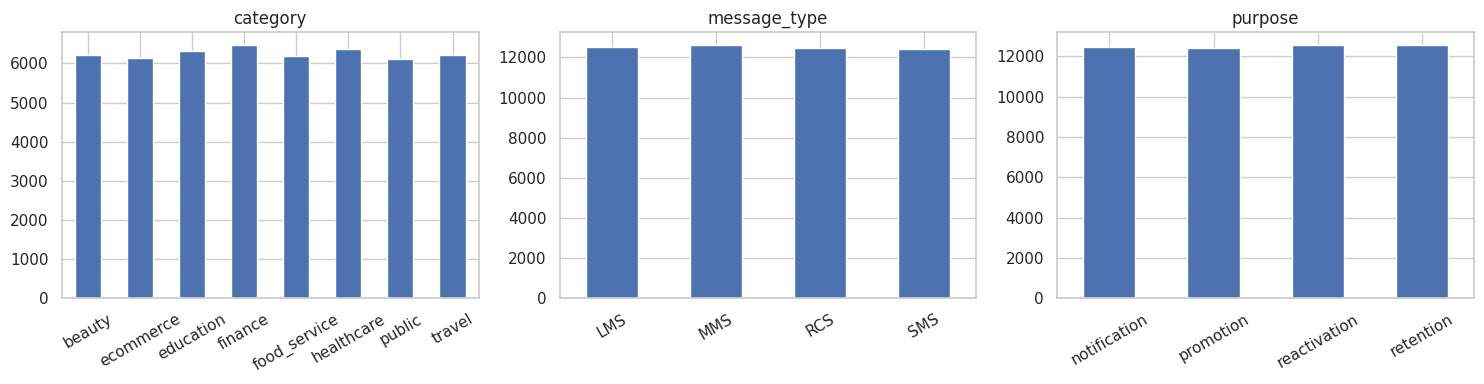

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["category", "message_type", "purpose"]):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 2. 시간대 효과 — 가정이 데이터에 살아있는가?

`HOUR_WEIGHTS_BY_CATEGORY`에 정의한 패턴(외식 11/17시 피크, 금융 9-11시 피크 등)이
생성된 데이터에서 시간대별 평균 전환율로 다시 보여야 한다.

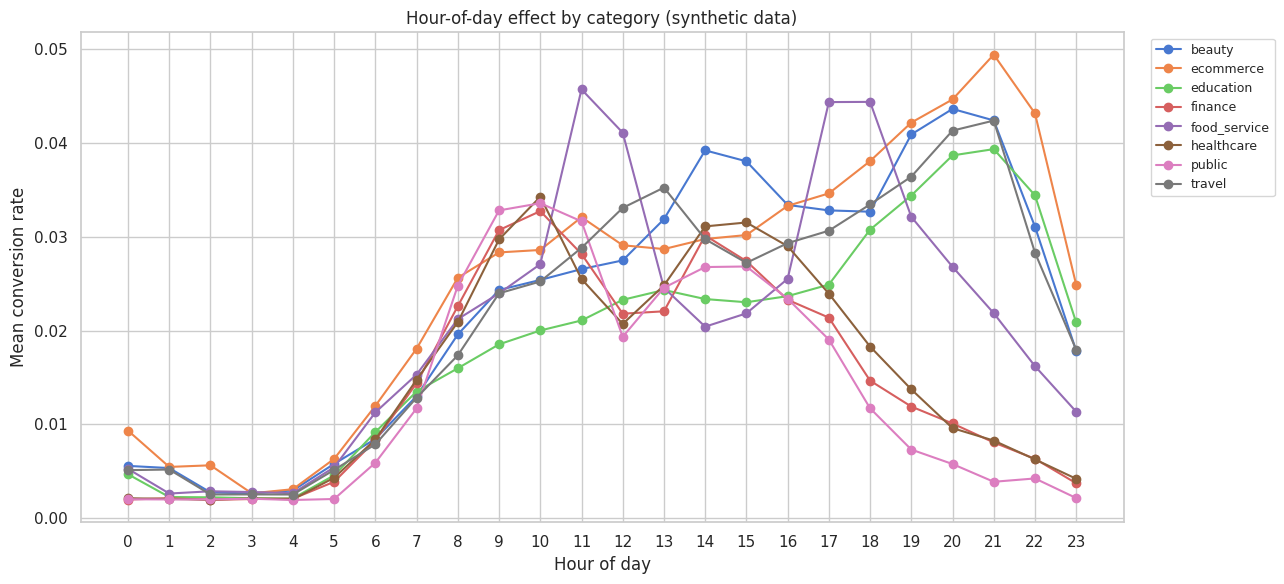

In [5]:
hourly = df.groupby(["category", "hour"])["conversion_rate"].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(13, 6))
for cat in hourly.columns:
    ax.plot(hourly.index, hourly[cat], marker="o", label=cat, linewidth=1.5)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean conversion rate")
ax.set_title("Hour-of-day effect by category (synthetic data)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

예상 패턴 체크:
- **food_service**: 11~12, 17~19시 피크
- **finance**: 9~11시 피크
- **ecommerce / beauty**: 저녁 20~22시 강세
- **public**: 오전 9~11시 집중


## 3. 요일 효과

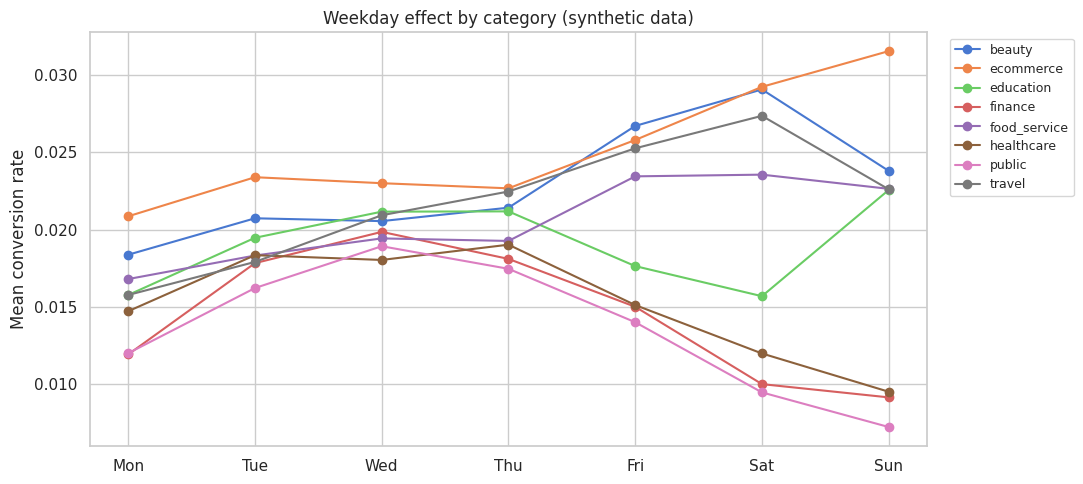

In [6]:
weekly = df.groupby(["category", "weekday"])["conversion_rate"].mean().unstack(level=0)
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(11, 5))
for cat in weekly.columns:
    ax.plot(weekly.index, weekly[cat], marker="o", label=cat, linewidth=1.5)
ax.set_xticks(range(0, 7))
ax.set_xticklabels(weekday_labels)
ax.set_ylabel("Mean conversion rate")
ax.set_title("Weekday effect by category (synthetic data)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

예상 패턴:
- **food_service / ecommerce / beauty / travel**: 주말 강세
- **finance / public / healthcare**: 화·수·목 평일 강세, 주말 약세


## 4. 메시지 타입 효과

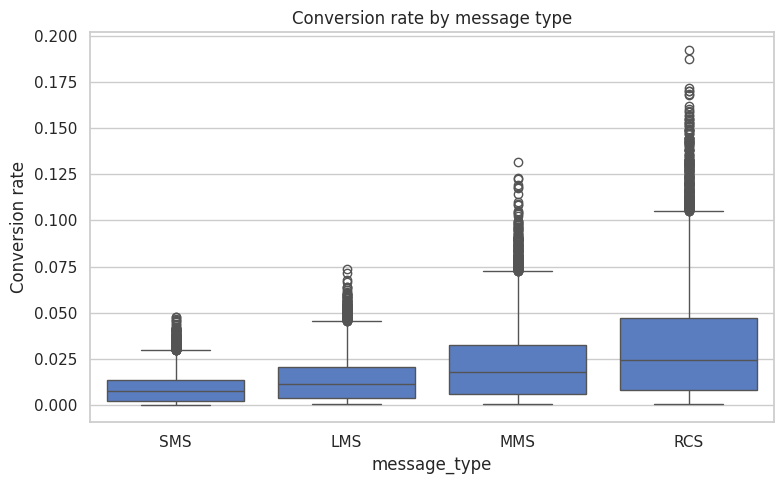

message_type
SMS    0.0089
LMS    0.0137
MMS    0.0219
RCS    0.0317
Name: conversion_rate, dtype: float64


In [7]:
type_order = ["SMS", "LMS", "MMS", "RCS"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="message_type", y="conversion_rate", order=type_order, ax=ax)
ax.set_title("Conversion rate by message type")
ax.set_ylabel("Conversion rate")
plt.tight_layout()
plt.show()

print(df.groupby("message_type")["conversion_rate"].mean().reindex(type_order).round(4))

기대: SMS < LMS < MMS < RCS 순으로 중앙값이 계단처럼 올라가야 함.

## 5. 캠페인 목적 효과

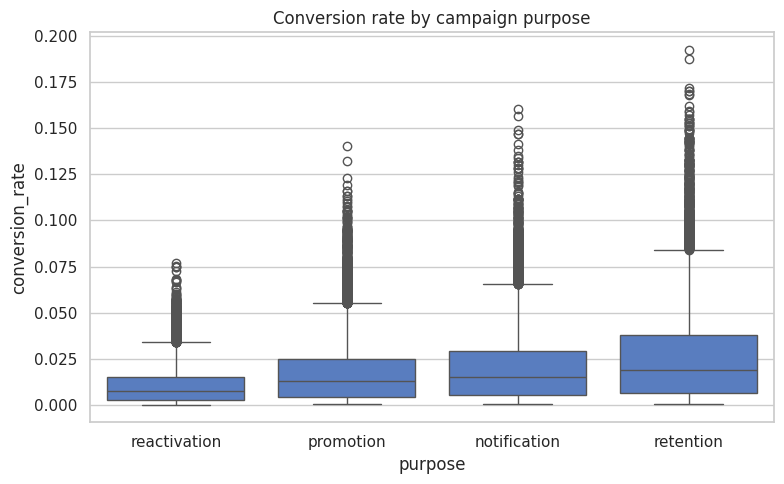

purpose
reactivation    0.0107
promotion       0.0179
notification    0.0211
retention       0.0266
Name: conversion_rate, dtype: float64


In [8]:
purpose_order = ["reactivation", "promotion", "notification", "retention"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="purpose", y="conversion_rate", order=purpose_order, ax=ax)
ax.set_title("Conversion rate by campaign purpose")
plt.tight_layout()
plt.show()

print(df.groupby("purpose")["conversion_rate"].mean().reindex(purpose_order).round(4))

기대 멀티플라이어: reactivation(0.6×) < promotion(1.0×) < notification(1.2×) < retention(1.5×).

## 6. 깔때기 검증

평균 비율:
open_rate          0.4526
click_rate         0.0763
conversion_rate    0.0191
dtype: float64

open > click > conversion ? True


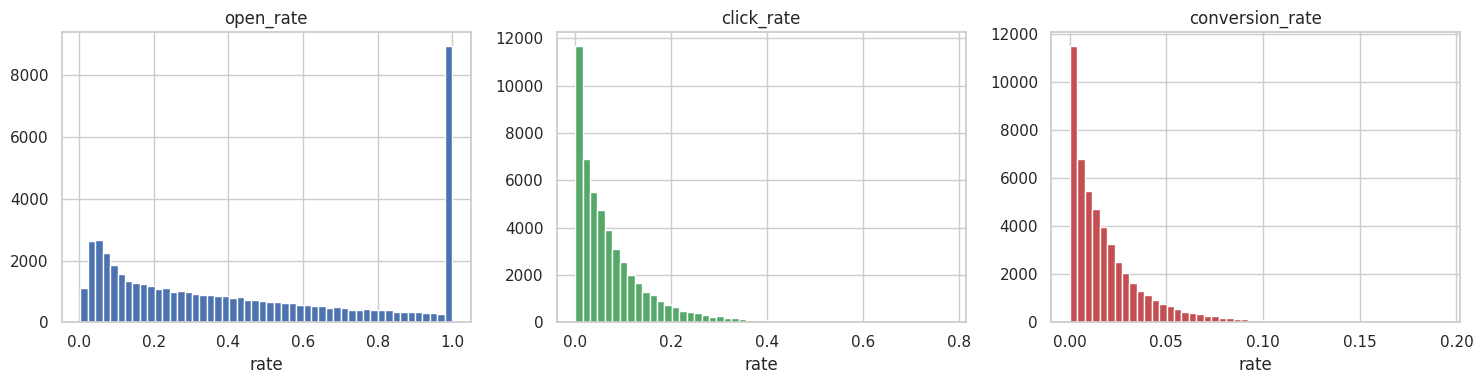

In [9]:
funnel = df[["open_rate", "click_rate", "conversion_rate"]].mean()
print("평균 비율:")
print(funnel.round(4))
print(f"\nopen > click > conversion ? {(funnel.iloc[0] > funnel.iloc[1] > funnel.iloc[2])}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes,
                          ["open_rate", "click_rate", "conversion_rate"],
                          ["#4C72B0", "#55A868", "#C44E52"]):
    ax.hist(df[col], bins=50, color=color, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("rate")
plt.tight_layout()
plt.show()

## 결론

가정(`patterns.py`)이 데이터에 시각적으로 재현됨을 확인. 이 데이터셋을 입력으로 다음
단계에서 발송 시간/전환율/세그먼트 예측 모델을 학습한다.
